In [1]:
from scipy.integrate import odeint
import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad 
from scipy import integrate
import numpy as np, matplotlib.pyplot as plt


c = 2.99792458e10  # cm/s
Msun = 1.989e33  # g
day = 24*3600  # s
pi = 3.14159265359
tau_Ni = 8.8*day  # s
tau_Co = 111.3*day  # s
e_Ni = 3.9e10  # erg/s/g
e_Co = 6.78e9  # erg/s/g
Mej = 10*Msun    # mass of ejecta
M_Ni= 0.1*Msun   # mass of 56Ni
Rmax0 = 1e14 # cm
Ek = 1*1e51 # erg
kappa = 0.2  # cm^2/g
x0 = 0.1
delta = 0
n = 10
Im = x0**3/(3-delta)+(x0**n-x0**3)/(3-n)
Ik = x0**5/(5-delta)+(x0**n-x0**5)/(5-n)
rho0 = Mej/(4*pi*Im*Rmax0**3)  # g/cm^3
v_max = (2*Ek*Im/(Mej*Ik))**(1/2)   # cm/s
beta = 13.8
tau_m = (2*kappa*Mej/(beta*c*v_max))**(1/2)


L_Ni0 = M_Ni*(e_Ni-e_Co)
y = tau_m/tau_Ni
z = tau_m/tau_Co

# x = symbols('x')

In [2]:
def f_int(x1):
    return x1*np.exp(x1**2)*(np.exp(-x1*y)+e_Co*np.exp(-x1*z)/(e_Ni-e_Co))

In [3]:
def f_rad(x):
    return quad(f_int,0,x)[0]

In [4]:
def L_rad(x):
    return 2*L_Ni0*np.exp(-x*x)*f_rad(x)

L_rad_vec = np.vectorize(L_rad)

In [9]:
L_rad(1)

1.2664954210426032e+42

In [10]:
x_s = np.linspace(0,20,300)


In [11]:
x_s

array([ 0.        ,  0.06688963,  0.13377926,  0.2006689 ,  0.26755853,
        0.33444816,  0.40133779,  0.46822742,  0.53511706,  0.60200669,
        0.66889632,  0.73578595,  0.80267559,  0.86956522,  0.93645485,
        1.00334448,  1.07023411,  1.13712375,  1.20401338,  1.27090301,
        1.33779264,  1.40468227,  1.47157191,  1.53846154,  1.60535117,
        1.6722408 ,  1.73913043,  1.80602007,  1.8729097 ,  1.93979933,
        2.00668896,  2.0735786 ,  2.14046823,  2.20735786,  2.27424749,
        2.34113712,  2.40802676,  2.47491639,  2.54180602,  2.60869565,
        2.67558528,  2.74247492,  2.80936455,  2.87625418,  2.94314381,
        3.01003344,  3.07692308,  3.14381271,  3.21070234,  3.27759197,
        3.34448161,  3.41137124,  3.47826087,  3.5451505 ,  3.61204013,
        3.67892977,  3.7458194 ,  3.81270903,  3.87959866,  3.94648829,
        4.01337793,  4.08026756,  4.14715719,  4.21404682,  4.28093645,
        4.34782609,  4.41471572,  4.48160535,  4.54849498,  4.61

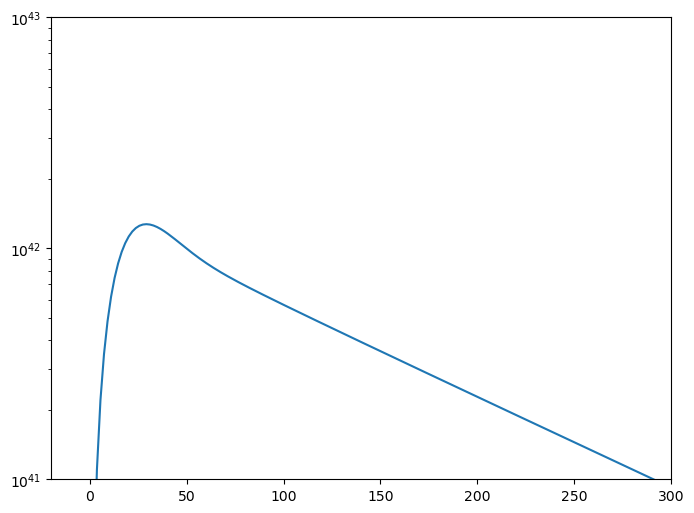

<Figure size 800x600 with 0 Axes>

In [13]:
fig = plt.figure(figsize=(8, 6))
plt.plot(x_s*tau_m/day, L_rad_vec(x_s))
plt.ylim(1e41, 1e43)
plt.xlim(-20, 300)
plt.yscale('log')
plt.show()
# def tempt(t):
#     return integrate(x*exp(-x**2)*(exp(-x*y)-e_Co*exp(-x*z)/(e_Ni-e_Co)),(x,0,t))

# def L_rad(x): 
#     return 2*L_Ni0*exp(-x**2)*tempt(x)
# %matplotlib inline

fig = plt.figure(figsize=(8, 6))

#     plt.plot(t_s/day,L_rad(t_s),'y--', lw=3,label='radioactive decay')
#     plt.xlabel('Time (days)',fontsize=18)
#     plt.ylabel(r'Luminosity ( erg s$^{-1}$)',fontsize=18)
#     plt.xticks(fontsize=10)
#     plt.yticks(fontsize=10)
#     plt.legend(fontsize=14)
#     plt.ylim(1e41, 1e43)
#     plt.xlim(-20, 300)
#     plt.yscale('log')
#     plt.show()
